# ST1504 CA2 Part A: CIFAR-10 Image Generation

## Objective

The objective of this project is to build and evaluate a generative deep learning model capable of generating CIFAR-10 images.

The CIFAR-10 dataset contains 60,000 colour images of size 32 × 32 pixels across 10 classes:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In this project, a Variational Autoencoder (VAE) / Generative Adversarial Network (GAN) will be trained to generate new images that resemble the original CIFAR-10 dataset.

In [7]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


In [8]:
import tarfile
import os

archive_path = "cifar-10-batches-py.tar.gz"

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(".")

print("Extraction complete")
print(os.listdir("."))

Extraction complete
['.git', '.gitignore', 'cifar-10-batches-py', 'cifar-10-batches-py.tar.gz', 'PtA.ipynb']


In [9]:
from tensorflow.keras.datasets import cifar10
import pickle
import numpy as np
import os

dataset_path = "cifar-10-batches-py"


def load_cifar_batch(file_path):
    with open(file_path, "rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = np.array(batch[b"labels"])

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels

In [10]:
x_train_batches = []
y_train_batches = []

for batch_number in range(1, 6):
    batch_path = os.path.join(
        dataset_path,
        f"data_batch_{batch_number}"
    )

    images, labels = load_cifar_batch(batch_path)

    x_train_batches.append(images)
    y_train_batches.append(labels)

x_train = np.concatenate(x_train_batches)
y_train = np.concatenate(y_train_batches)

x_test, y_test = load_cifar_batch(
    os.path.join(dataset_path, "test_batch")
)

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


# EDA

In [ ]:
# 1. Inspect the dataset structure
print("Training image shape:", x_train.shape)
print("Training label shape:", y_train.shape)

print("Image data type:", x_train.dtype)
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Training image shape: (50000, 32, 32, 3)
Training label shape: (50000,)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
# 2. Check the labels
print(y_train[:20])

[6 9 9 4 1 1 2 7 8 3 4 7 7 2 9 9 9 3 2 6]


In [14]:
unique_labels = np.unique(y_train)

print("Unique labels:", unique_labels)
print("Number of classes:", len(unique_labels))

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


In [15]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

The labels are represented as integers from 0 to 9. Each integer corresponds to one CIFAR-10 class. A class-name list is used to convert the numerical labels into readable names.

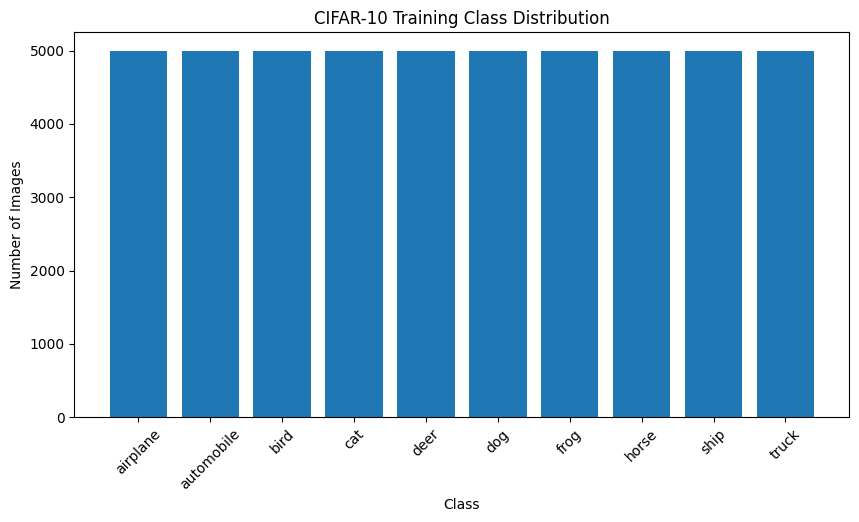

airplane 5000
automobile 5000
bird 5000
cat 5000
deer 5000
dog 5000
frog 5000
horse 5000
ship 5000
truck 5000


In [16]:
# 3. Class Distribution
class_counts = np.bincount(y_train, minlength=10)
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)

plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

for class_index, count in enumerate(class_counts):
    print(class_names[class_index], count)

In [ ]:
# 4. Display Random Training Images

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(x_train), size=20, replace=False)

In [18]:
# 5. Display examples class by class
class_id = 3
class_indices = np.where(y_train == class_id)[0]

print("Selected class:", class_names[class_id])
print("Number of images:", len(class_indices))

Selected class: cat
Number of images: 5000


Average brightness: 120.7075651236979
Minimum image brightness: 7.8837890625
Maximum image brightness: 252.296875


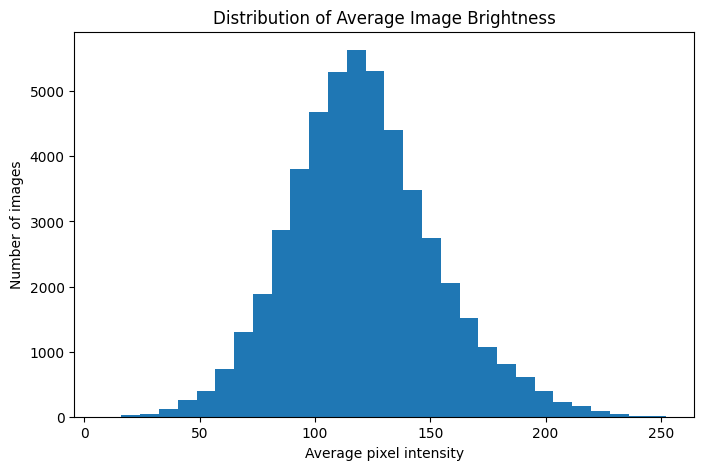

In [20]:
# 6. Examine Image Brightness 

mean_brightness = x_train.mean(axis=(1, 2, 3))

print("Average brightness:", mean_brightness.mean())
print("Minimum image brightness:", mean_brightness.min())
print("Maximum image brightness:", mean_brightness.max())

plt.figure(figsize=(8, 5))
plt.hist(mean_brightness, bins=30)

plt.title("Distribution of Average Image Brightness")
plt.xlabel("Average pixel intensity")
plt.ylabel("Number of images")

plt.show()

In [23]:
# 7. RGB Colour Channels

channel_means = x_train.mean(axis=(0, 1, 2))
channel_stds = x_train.std(axis=(0, 1, 2))

print("Channel means:", channel_means)
print("Channel standard deviations:", channel_stds)


Channel means: [125.30691805 122.95039414 113.86538318]
Channel standard deviations: [62.99321928 62.08870764 66.70489964]


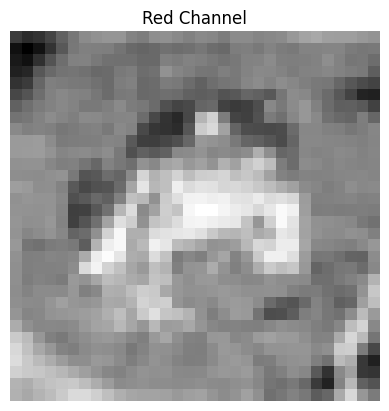

In [24]:
plt.imshow(image[:, :, 0], cmap="gray")
plt.title("Red Channel")
plt.axis("off")
plt.show()

In [25]:
# 9. Compare class brightness or colour

for class_id in range(10):
    class_images = x_train[y_train == class_id]
    average = class_images.mean()

    print(class_names[class_id], average)

airplane 142.365784765625
automobile 116.69753678385416
bird 119.405596484375
cat 116.23182356770833
deer 111.77529895833334
dog 117.39423971354167
frog 106.5619337890625
horse 118.89019752604166
ship 133.47602604166667
truck 124.27721360677083


In [26]:
# 10. Check for missing or invalid values

print("Missing values:", np.isnan(x_train).sum())
print("Infinite values:", np.isinf(x_train).sum())

Missing values: 0
Infinite values: 0


In [27]:
# 11. Check for Completely Blank Images
image_variances = x_train.var(axis=(1, 2, 3))

blank_like_count = np.sum(image_variances == 0)

print("Images with zero variance:", blank_like_count)

Images with zero variance: 0


In [28]:
# 12. Compare Training and test Distribution

train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

print("Training counts:", train_counts)
print("Test counts:", test_counts)

Training counts: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]
Test counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


# Preprocess